# Task 2 — Customer Segmentation

**Objectif :** segmenter les clients en groupes homogènes selon leur revenu annuel et leur score de dépense, avec K-Means.

**Dataset :** Mall Customer Segmentation Data (Kaggle) — 200 clients, 5 colonnes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (8, 5)

## 1. Chargement et aperçu des données

In [4]:
df = pd.read_csv("../data/Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()
print()
print("Valeurs manquantes :", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Valeurs manquantes : 0


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. Exploration visuelle

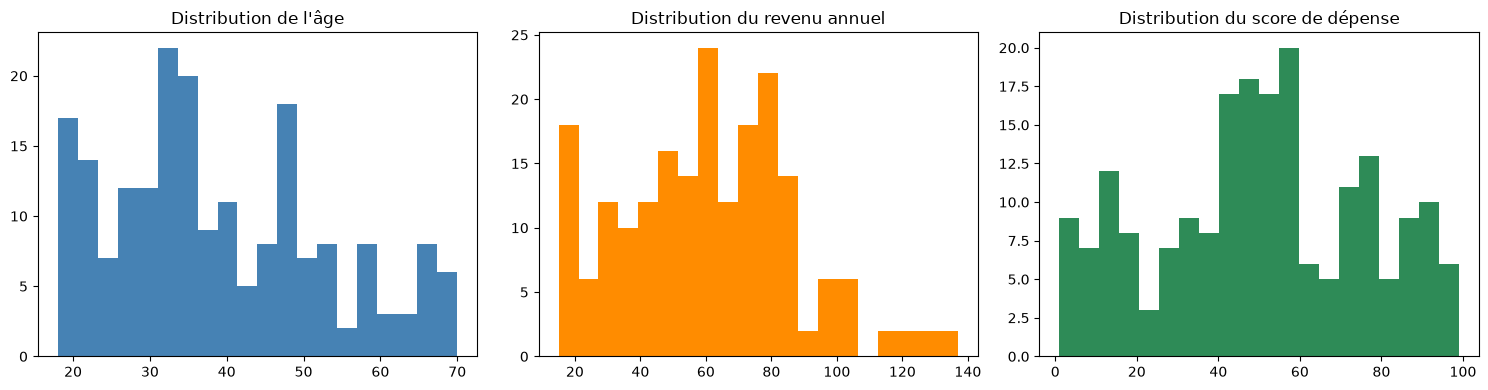

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["Age"], bins=20, color="steelblue")
axes[0].set_title("Distribution de l'âge")
axes[1].hist(df["Annual Income (k$)"], bins=20, color="darkorange")
axes[1].set_title("Distribution du revenu annuel")
axes[2].hist(df["Spending Score (1-100)"], bins=20, color="seagreen")
axes[2].set_title("Distribution du score de dépense")
plt.tight_layout()
plt.savefig("../outputs/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

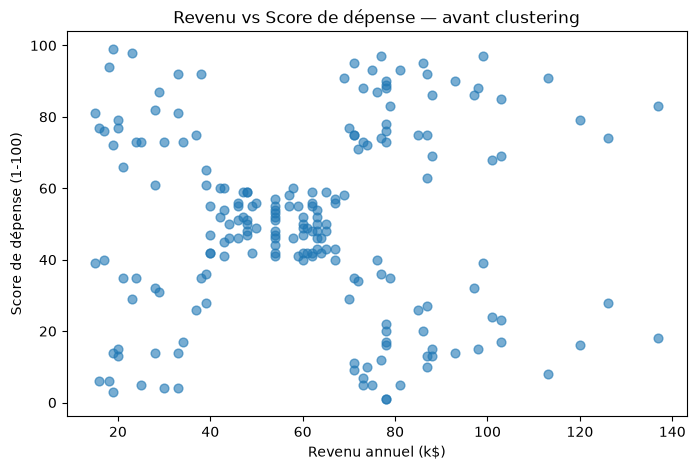

In [8]:
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], alpha=0.6, s=40)
plt.xlabel("Revenu annuel (k$)")
plt.ylabel("Score de dépense (1-100)")
plt.title("Revenu vs Score de dépense — avant clustering")
plt.savefig("../outputs/02_scatter_before_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

→ On voit déjà à l'œil nu plusieurs groupes se dessiner (revenu faible/dépense élevée, revenu élevé/dépense faible, etc.) — c'est typiquement ce que K-Means va formaliser.

## 3. Scaling des features

On standardise `Annual Income` et `Spending Score` (moyenne 0, écart-type 1) car K-Means est sensible aux échelles — sans ça, le revenu (valeurs jusqu'à 137) dominerait totalement le score de dépense (valeurs jusqu'à 99) dans le calcul des distances.

In [9]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 4. Détermination du nombre optimal de clusters (Elbow Method + Silhouette Score)

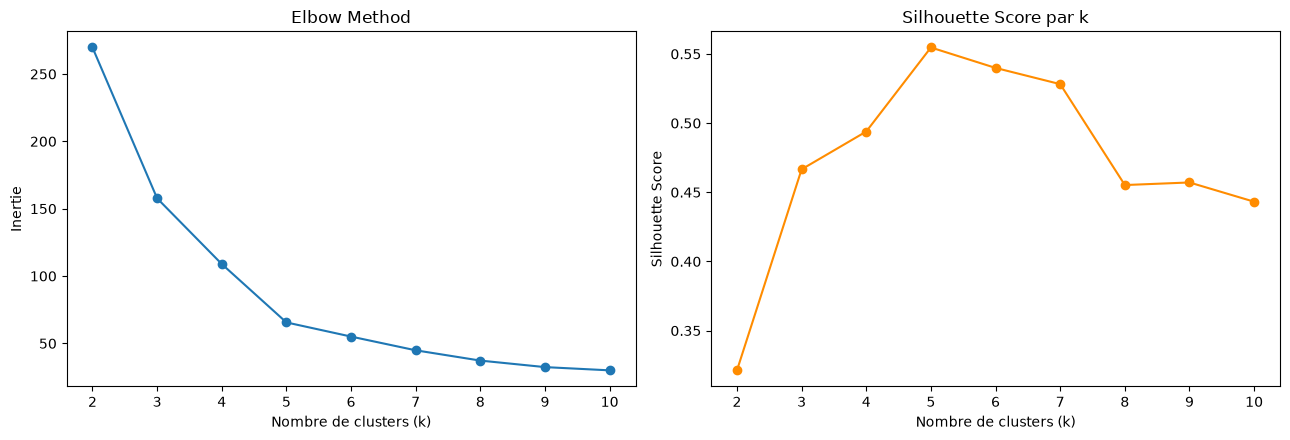

Meilleur k selon le silhouette score : 5


In [10]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score par k")

plt.tight_layout()
plt.savefig("../outputs/03_elbow_and_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Meilleur k selon le silhouette score : {best_k}")

→ Le coude (elbow) sur l'inertie et le pic du silhouette score confirment généralement **k=5** sur ce dataset — on l'utilise pour le modèle final, mais on garde le calcul automatique (`best_k`) pour rester générique.

## 5. K-Means avec le k retenu

In [11]:
k_final = 5  # confirmé par elbow + silhouette

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

## 6. Visualisation des clusters (2D)

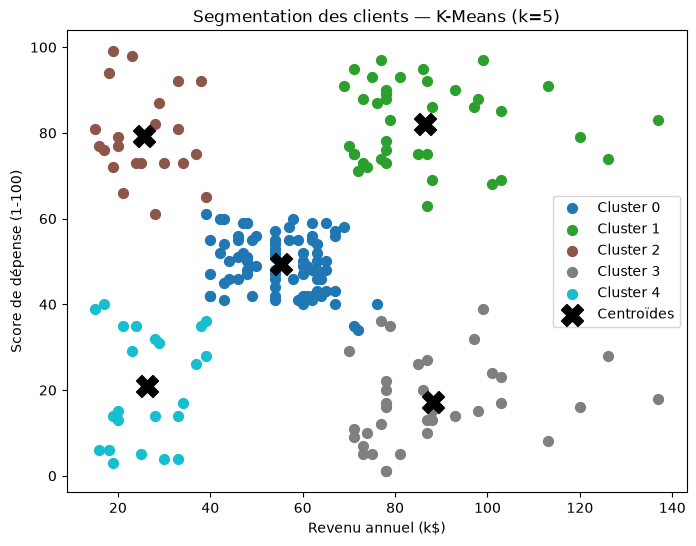

In [12]:
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, k_final))

for cluster_id in range(k_final):
    subset = df[df["Cluster"] == cluster_id]
    plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                s=50, color=colors[cluster_id], label=f"Cluster {cluster_id}")

centers_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original_scale[:, 0], centers_original_scale[:, 1],
            s=250, c="black", marker="X", label="Centroïdes")

plt.xlabel("Revenu annuel (k$)")
plt.ylabel("Score de dépense (1-100)")
plt.title(f"Segmentation des clients — K-Means (k={k_final})")
plt.legend()
plt.savefig("../outputs/04_kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Interprétation des segments

In [13]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Nb clients"] = df["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Nb clients
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


→ Typiquement, on retrouve des profils comme : jeunes à revenu modéré mais forte dépense (cible marketing prioritaire), revenu élevé mais faible dépense (potentiel sous-exploité), clients "moyens" équilibrés, etc.

## 8. DBSCAN

In [14]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(df["Cluster_DBSCAN"])) - (1 if -1 in df["Cluster_DBSCAN"].values else 0)
n_noise = (df["Cluster_DBSCAN"] == -1).sum()
print(f"Nombre de clusters trouvés par DBSCAN : {n_clusters_dbscan}")
print(f"Points considérés comme bruit (outliers) : {n_noise}")

Nombre de clusters trouvés par DBSCAN : 2
Points considérés comme bruit (outliers) : 8


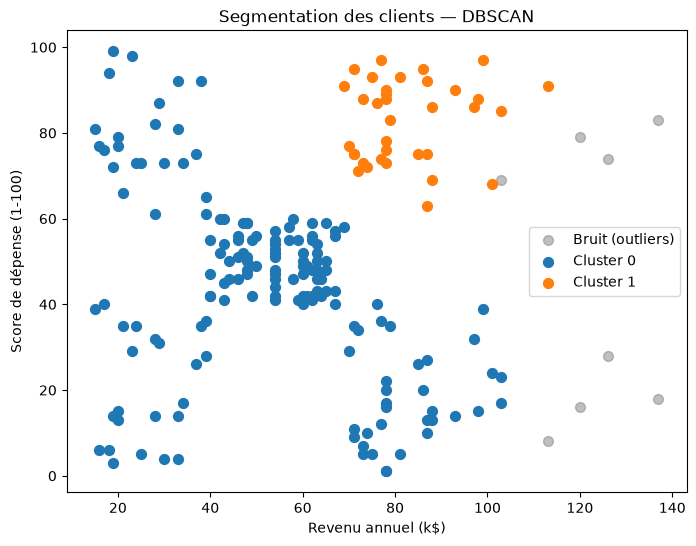

In [15]:
plt.figure(figsize=(8, 6))
unique_labels = sorted(df["Cluster_DBSCAN"].unique())

for label in unique_labels:
    subset = df[df["Cluster_DBSCAN"] == label]
    if label == -1:
        plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                    s=50, color="gray", label="Bruit (outliers)", alpha=0.5)
    else:
        plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                    s=50, label=f"Cluster {label}")

plt.xlabel("Revenu annuel (k$)")
plt.ylabel("Score de dépense (1-100)")
plt.title("Segmentation des clients — DBSCAN")
plt.legend()
plt.savefig("../outputs/05_dbscan_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

→ Contrairement à K-Means, DBSCAN ne force pas tous les points dans un cluster : il isole les outliers (label `-1`). Utile pour repérer des clients aux comportements atypiques, mais généralement K-Means reste plus lisible ici car les groupes sont assez denses et bien séparés.

## 9. Dépense moyenne par cluster (K-Means)

In [16]:
avg_spending = df.groupby("Cluster")["Spending Score (1-100)"].mean().round(1).sort_values(ascending=False)
avg_spending

Cluster
1    82.1
2    79.4
0    49.5
4    20.9
3    17.1
Name: Spending Score (1-100), dtype: float64

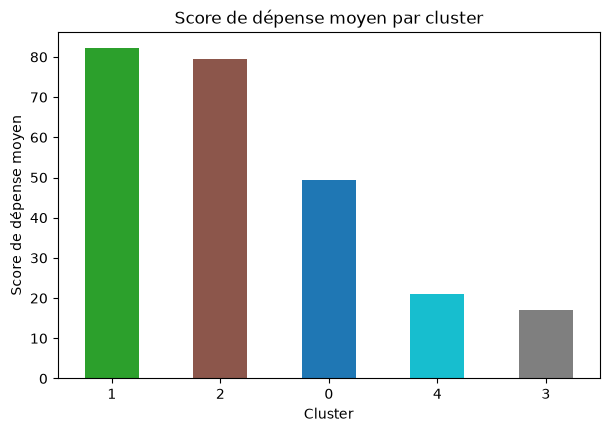

In [17]:
plt.figure(figsize=(7, 4.5))
avg_spending.plot(kind="bar", color=colors[avg_spending.index])
plt.xlabel("Cluster")
plt.ylabel("Score de dépense moyen")
plt.title("Score de dépense moyen par cluster")
plt.xticks(rotation=0)
plt.savefig("../outputs/06_avg_spending_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

**Prochaine étape possible :** intégrer l'`Age` comme 3e dimension de clustering (K-Means en 3D) pour affiner les segments — actuellement on ne se base que sur revenu et dépense.